In [ ]:
# Import Required Libraries

# Used for reading and handling datasets
import pandas as pd

# Used for numerical operations
import numpy as np

# Used for creating graphs and charts
import matplotlib.pyplot as plt

# Used to convert categorical data into numbers
from sklearn.preprocessing import LabelEncoder

# Machine Learning Algorithm
from sklearn.ensemble import RandomForestClassifier

# Used to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Used to evaluate model performance
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Used to save the trained model
import joblib

In [3]:
# Load the Dataset

df = pd.read_csv("Instagram_Analytics.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
# Display the first five rows of the dataset

df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [5]:
# Display the last five rows of the dataset

df.tail()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
29994,IG0029995,5,brand,10739,carousel,Travel,Reels Feed,0,2024-12-18 10:00:00,2024-12-18,...,1,2,5,1564,2493,0.0032,124,127,8,low
29995,IG0029996,3,brand,10018,image,Beauty,Hashtags,0,2025-05-05 15:00:00,2025-05-05,...,2,1,7,2042,2492,0.0209,310,114,12,low
29996,IG0029997,18,creator,7486,image,Photography,Explore,1,2025-05-26 10:00:00,2025-05-26,...,10,16,59,5887,7528,0.0558,223,115,4,high
29997,IG0029998,6,creator,10034,carousel,Technology,Explore,1,2025-08-02 19:00:00,2025-08-02,...,3,0,19,5372,6312,0.0333,978,124,4,medium
29998,IG0029999,9,creator,6916,image,Technology,Explore,1,2025-04-15 20:00:00,2025-04-15,...,1,1,5,4019,5678,0.0100,272,126,11,low


In [7]:
# Display 5 random rows from the dataset

df.sample(5)

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
25413,IG0025414,14,creator,3083,image,Beauty,External,1,2025-05-06 06:00:00,2025-05-06,...,2,1,16,1300,2038,0.0456,269,112,7,high
12005,IG0012006,1,creator,9461,carousel,Fitness,Explore,1,2024-11-21 02:00:00,2024-11-21,...,11,24,62,20768,27846,0.0194,687,138,7,low
5216,IG0005217,9,creator,6916,reel,Photography,Reels Feed,1,2025-03-19 19:00:00,2025-03-19,...,10,6,24,6723,10474,0.0192,325,96,13,low
23809,IG0023810,13,creator,5824,image,Fashion,Profile,0,2025-04-02 05:00:00,2025-04-02,...,10,7,24,2073,3144,0.0576,95,120,6,high
10120,IG0010121,11,creator,9044,carousel,Beauty,Explore,0,2025-10-15 20:00:00,2025-10-15,...,16,29,46,10476,16016,0.0363,313,115,3,medium


In [8]:
# Explore the Dataset

# Number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(29999, 23)

Column Names:
Index(['post_id', 'account_id', 'account_type', 'follower_count', 'media_type',
       'content_category', 'traffic_source', 'has_call_to_action',
       'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes',
       'comments', 'shares', 'saves', 'reach', 'impressions',
       'engagement_rate', 'followers_gained', 'caption_length',
       'hashtags_count', 'performance_bucket_label'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_catego

In [9]:
# Statistical Summary & Duplicate Check

# Display statistical summary
print("Statistical Summary:")
print(df.describe())

# Check duplicate records
print("\nDuplicate Records:")
print(df.duplicated().sum())

Statistical Summary:
         account_id  follower_count  has_call_to_action     post_hour  \
count  29999.000000    29999.000000        29999.000000  29999.000000   
mean      10.567819    10278.305477            0.348778     11.499417   
std        5.763952     6691.862669            0.476592      6.900587   
min        1.000000     3083.000000            0.000000      0.000000   
25%        6.000000     5824.000000            0.000000      6.000000   
50%       11.000000     9044.000000            0.000000     12.000000   
75%       16.000000    10739.000000            1.000000     17.000000   
max       20.000000    31095.000000            1.000000     23.000000   

              likes      comments        shares         saves         reach  \
count  29999.000000  29999.000000  29999.000000  29999.000000  29999.000000   
mean     287.653588      8.521917     14.426614     42.517284   6272.475449   
std      317.647682     10.116505     16.420899     47.808844   4985.877059   
min  

In [10]:
# Feature Selection

# Remove unnecessary columns

df = df.drop(
    ['post_id', 'account_id', 'post_datetime', 'post_date'],
    axis=1
)

# Display remaining columns
print("Remaining Columns:")
print(df.columns)

# Display new dataset shape
print("\nNew Dataset Shape:")
print(df.shape)

Remaining Columns:
Index(['account_type', 'follower_count', 'media_type', 'content_category',
       'traffic_source', 'has_call_to_action', 'post_hour', 'day_of_week',
       'likes', 'comments', 'shares', 'saves', 'reach', 'impressions',
       'engagement_rate', 'followers_gained', 'caption_length',
       'hashtags_count', 'performance_bucket_label'],
      dtype='object')

New Dataset Shape:
(29999, 19)


performance_bucket_label
viral     7500
high      7500
low       7500
medium    7499
Name: count, dtype: int64


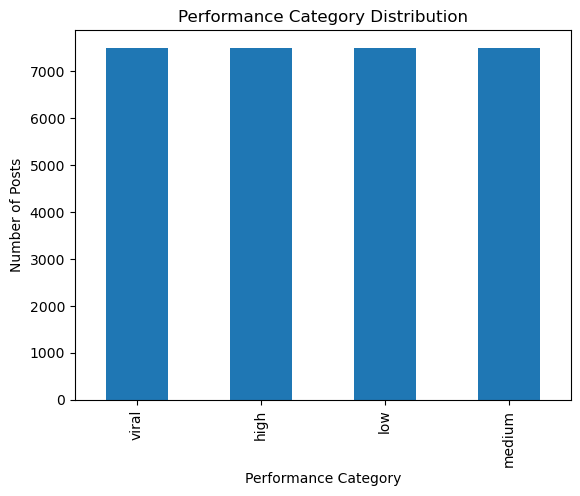

In [11]:
# Target Variable Distribution

# Count the number of posts in each performance category
print(df['performance_bucket_label'].value_counts())

# Create a bar chart
df['performance_bucket_label'].value_counts().plot(kind='bar')

plt.title("Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Posts")

plt.show()

In [12]:
# Label Encoding

# Dictionary to store all label encoders
encoders = {}

# List of categorical columns
categorical_columns = [
    'account_type',
    'media_type',
    'content_category',
    'traffic_source',
    'day_of_week',
    'performance_bucket_label'
]

# Apply Label Encoding to each categorical column
for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

# Display the updated dataset
print(df.head())

# Check data types
print("\nDataset Information:")
print(df.info())

   account_type  follower_count  media_type  content_category  traffic_source  \
0             0            3551           2                 8               3   
1             1           31095           1                 3               2   
2             0            8167           2                 0               5   
3             1            9044           0                 6               1   
4             1           15986           2                 8               4   

   has_call_to_action  post_hour  day_of_week  likes  comments  shares  saves  \
0                   1          6            2    194         5       7     34   
1                   1         15            0    449        10      21     68   
2                   0         16            4    114         2       1     22   
3                   0          3            4     91         0       7      0   
4                   0          9            0    154         8       5     21   

   reach  impressions  eng

In [13]:
# Split Dataset into Features and Target

# Features (Input)
X = df.drop('performance_bucket_label', axis=1)

# Target (Output)
y = df['performance_bucket_label']

# Display Shapes
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (29999, 18)
Target Shape: (29999,)


In [15]:
# Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shape of each dataset
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (23999, 18)
X_test Shape: (6000, 18)
y_train Shape: (23999,)
y_test Shape: (6000,)


In [ ]:
# Build and Train the Random Forest Model

# Create the Random Forest model
model = RandomForestClassifier(random_state=42)

# Train the model using training data
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [18]:
# Make Predictions and Calculate Accuracy

# Predict the performance of test data
y_pred = model.predict(X_test)

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8513333333333334


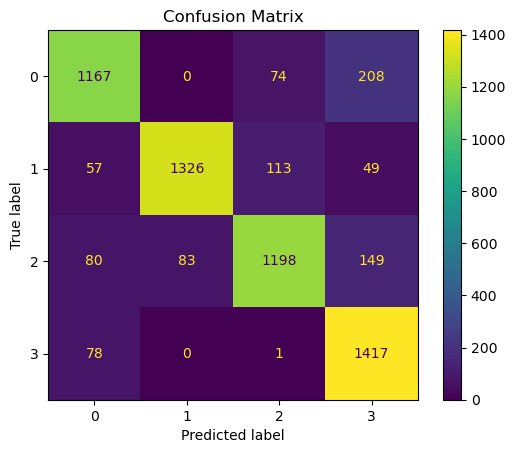

In [19]:
# Confusion Matrix

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [20]:
# Classification Report

print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.81      0.82      1449
           1       0.94      0.86      0.90      1545
           2       0.86      0.79      0.83      1510
           3       0.78      0.95      0.85      1496

    accuracy                           0.85      6000
   macro avg       0.86      0.85      0.85      6000
weighted avg       0.86      0.85      0.85      6000



               Feature  Importance
14     engagement_rate    0.525074
8                likes    0.101125
13         impressions    0.091735
12               reach    0.060705
11               saves    0.060530
10              shares    0.041261
9             comments    0.028199
15    followers_gained    0.014810
16      caption_length    0.013295
6            post_hour    0.011394
1       follower_count    0.010620
17      hashtags_count    0.009630
3     content_category    0.008688
7          day_of_week    0.007564
4       traffic_source    0.006823
2           media_type    0.004022
5   has_call_to_action    0.002376
0         account_type    0.002148


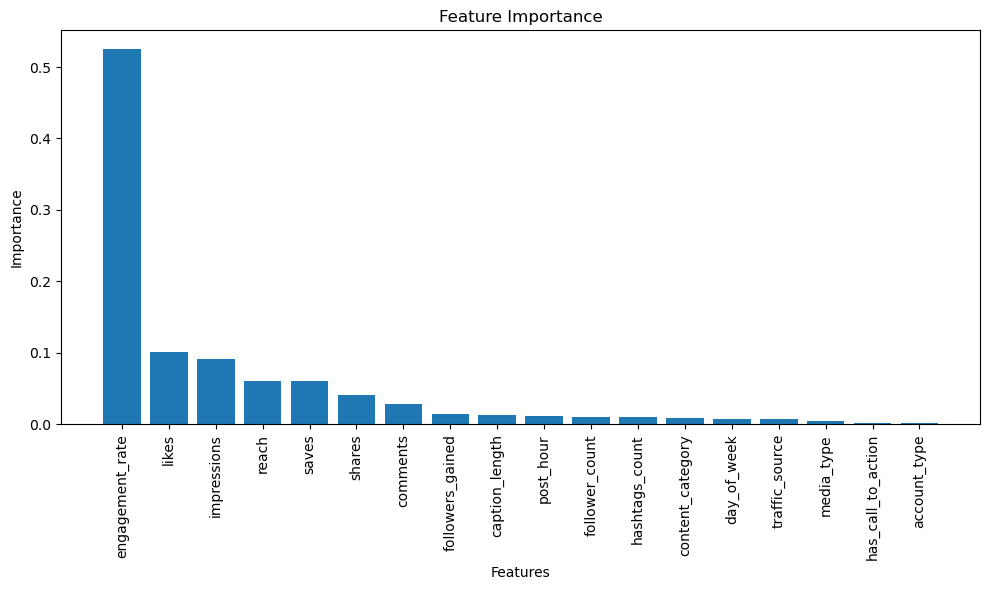

In [21]:
# Feature Importance

# Create a DataFrame containing feature names and their importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort the features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()

plt.show()

In [22]:
# Save Model and Label Encoders

import joblib

# Save the trained Random Forest model
joblib.dump(model, "instagram_model.pkl")

# Save all label encoders
joblib.dump(encoders, "label_encoders.pkl")

print("Model Saved Successfully!")
print("Label Encoders Saved Successfully!")

Model Saved Successfully!
Label Encoders Saved Successfully!
